# Original Notebook Source Located here, please scroll down to get to our auditing phase.



In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
#import kagglehub
# Source dataset by Pavansubhasht
#pavansubhasht_ibm_hr_analytics_attrition_dataset_path = kagglehub.dataset_download('pavansubhasht/ibm-hr-analytics-attrition-dataset')

#print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [ ]:
!pip install shap

In [ ]:
# Importing necessary libraries

#Added Imports for Fairness Analysis:
import shap
from sklearn.metrics import precision_recall_fscore_support
from itertools import combinations
import pandas as pd
import xgboost as xgb
#----------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
shap.initjs() #initialize SHAP (we'll use this later)

In [ ]:
import kagglehub
import os

# Download the dataset using kagglehub
# This will return the path to the downloaded dataset directory
dataset_dir = kagglehub.dataset_download('pavansubhasht/ibm-hr-analytics-attrition-dataset')

# Construct the full path to the CSV file within the downloaded directory
csv_file_path = os.path.join(dataset_dir, "WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Loading the dataset from the correct path
df=pd.read_csv(csv_file_path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.


In [ ]:
pd.set_option('Display.max_rows', None)
pd.set_option('Display.max_columns', None)

# **EDA**: Exploratory Data Analyis

In [ ]:
# Checking first 5 rows of dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [ ]:
# Checking null values in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

SInce there are no null values in this dataset, we can proceed with analyzing outliers in the dataset.

# **Preprocessing**

In [ ]:
# Target variable
y=df['Attrition']

In [ ]:
df=df.drop(['Attrition'], axis=1)

In [ ]:
# Extracting categorical columns into a seperate dataframe for analysis
categorical_col=df[['BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','Over18','OverTime']]
categorical_col.head()

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No


In [ ]:
def convert_cat_to_num(series):
    return pd.factorize(series)[0]

categorical_cols_encoded=categorical_col.apply(convert_cat_to_num)
categorical_cols_encoded.head()

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,0,0,0,0,0,0,0,0
1,1,1,0,1,1,1,0,1
2,0,1,1,1,2,0,0,0
3,1,1,0,0,1,1,0,0
4,0,1,2,1,2,1,0,1


In [ ]:
# Extracting numerical columns into a seperate dataframe for analysis
numerical_col=df.drop(columns=categorical_col)
numerical_col.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,4,5993,19479,8,11,3,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,2,5130,24907,1,23,4,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,3,2090,2396,6,15,3,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,3,2909,23159,1,11,3,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,2,3468,16632,9,12,3,4,80,1,6,3,3,2,2,2,2


In [ ]:
df_concat=pd.concat([numerical_col, categorical_cols_encoded], axis=1)
df_concat.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,41,1102,1,2,1,1,2,94,3,2,4,5993,19479,8,11,3,1,80,0,8,0,1,6,4,0,5,0,0,0,0,0,0,0,0
1,49,279,8,1,1,2,3,61,2,2,2,5130,24907,1,23,4,4,80,1,10,3,3,10,7,1,7,1,1,0,1,1,1,0,1
2,37,1373,2,2,1,4,4,92,2,1,3,2090,2396,6,15,3,2,80,0,7,3,3,0,0,0,0,0,1,1,1,2,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,3,2909,23159,1,11,3,3,80,0,8,3,3,8,7,3,0,1,1,0,0,1,1,0,0
4,27,591,2,1,1,7,1,40,3,1,2,3468,16632,9,12,3,4,80,1,6,3,3,2,2,2,2,0,1,2,1,2,1,0,1


In [ ]:
# Checking correleation between numerical columns
correlation = df_concat.corr()
correlation

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,0.028051,0.299635,0.003634,0.001904,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089,-0.024751,0.031882,-0.007192,-0.036311,0.159715,0.095029,NaN,-0.028062
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,-0.032182,0.038153,0.022704,0.000473,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363,0.004086,-0.007109,-0.015942,-0.011716,-0.002507,0.069586,NaN,-0.009135
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,0.027473,-0.029251,0.040235,0.027110,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406,0.024469,-0.017225,0.020004,-0.001851,-0.043595,0.014437,NaN,-0.025514
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,-0.026084,0.126317,-0.011111,-0.024539,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065,-0.000757,-0.007996,-0.002687,-0.016547,-0.019223,-0.004053,NaN,0.020322
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,-0.046247,-0.014829,0.012648,-0.001251,-0.012944,-0.020359,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197,0.015578,0.010895,0.007922,0.022556,0.015496,0.008155,NaN,0.024037
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,0.037600,0.012594,-0.031701,-0.029548,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999,-0.004174,0.019395,0.015744,0.000508,-0.010129,0.003593,NaN,-0.070132
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,-0.015297,0.022157,-0.009062,-0.002172,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123,-0.026528,0.004144,-0.023901,-0.000478,-0.020728,0.017861,NaN,0.007782
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,-0.016322,0.015012,-0.017205,-0.029071,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976,-0.039062,0.024586,-0.005582,0.017960,-0.006766,0.038497,NaN,0.003507
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,0.039563,0.142501,-0.034730,-0.021222,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281,-0.019311,-0.101963,0.009671,-0.039403,0.313588,0.076769,NaN,-0.000544


**Insights**:

* The relationship between Job Level, Monthly Income, and Total Working Years is very strong and positive (over 0.75) which shows employees with more experience tend to earn higher salaries.

* The correlation among Years at Company, Years in Current Role, and Years with Current Manager is significantly high (around 0.7–0.77), indicating that employees who stay longer at the company are likely to retain the same roles and managers.

* Age shows a positive relationship with Job Level (0.51) and Total Working Years (0.68), which implies that older employees are frequently in higher positions and possess more experience.

* Most of the other variables, including Daily Rate, Distance from Home, and Gender, exhibit weak or nearly nonexistent correlations, indicating a lack of linear relationships with the other factors.

* There is a strong correlation between Performance Rating and Percent Salary Hike (~0.77), which indicates that the increase in salary are closely tied to the performance assessments of employees.

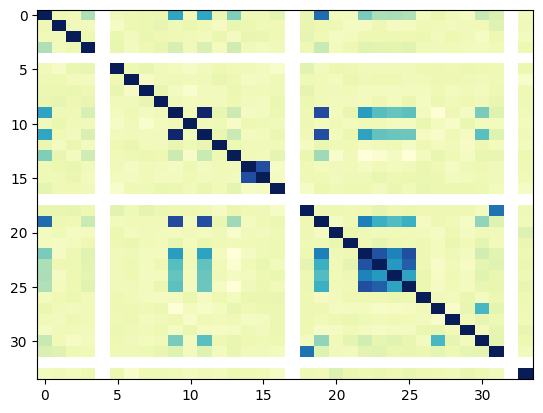

In [ ]:
# Heatmap
plt.imshow(df_concat.corr(), cmap='YlGnBu', aspect='auto')
plt.show()

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]),
 [Text(1, 0, 'Age'),
  Text(2, 0, 'DailyRate'),
  Text(3, 0, 'DistanceFromHome'),
  Text(4, 0, 'Education'),
  Text(5, 0, 'EmployeeCount'),
  Text(6, 0, 'EmployeeNumber'),
  Text(7, 0, 'EnvironmentSatisfaction'),
  Text(8, 0, 'HourlyRate'),
  Text(9, 0, 'JobInvolvement'),
  Text(10, 0, 'JobLevel'),
  Text(11, 0, 'JobSatisfaction'),
  Text(12, 0, 'MonthlyIncome'),
  Text(13, 0, 'MonthlyRate'),
  Text(14, 0, 'NumCompaniesWorked'),
  Text(15, 0, 'PercentSalaryHike'),
  Text(16, 0, 'PerformanceRating'),
  Text(17, 0, 'RelationshipSatisfaction'),
  Text(18, 0, 'StandardHours'),
  Text(19, 0, 'StockOptionLevel'),
  Text(20, 0, 'TotalWorkingYears'),
  Text(21, 0, 'TrainingTimesLastYear'),
  Text(22, 0, 'WorkLifeBalance'),
  Text(23, 0, 'YearsAtCompany'),
  Text(24, 0, 'YearsInCurrentRole'),
  Text(25, 0, 'YearsSinceLastPromotion'),
  Text(26

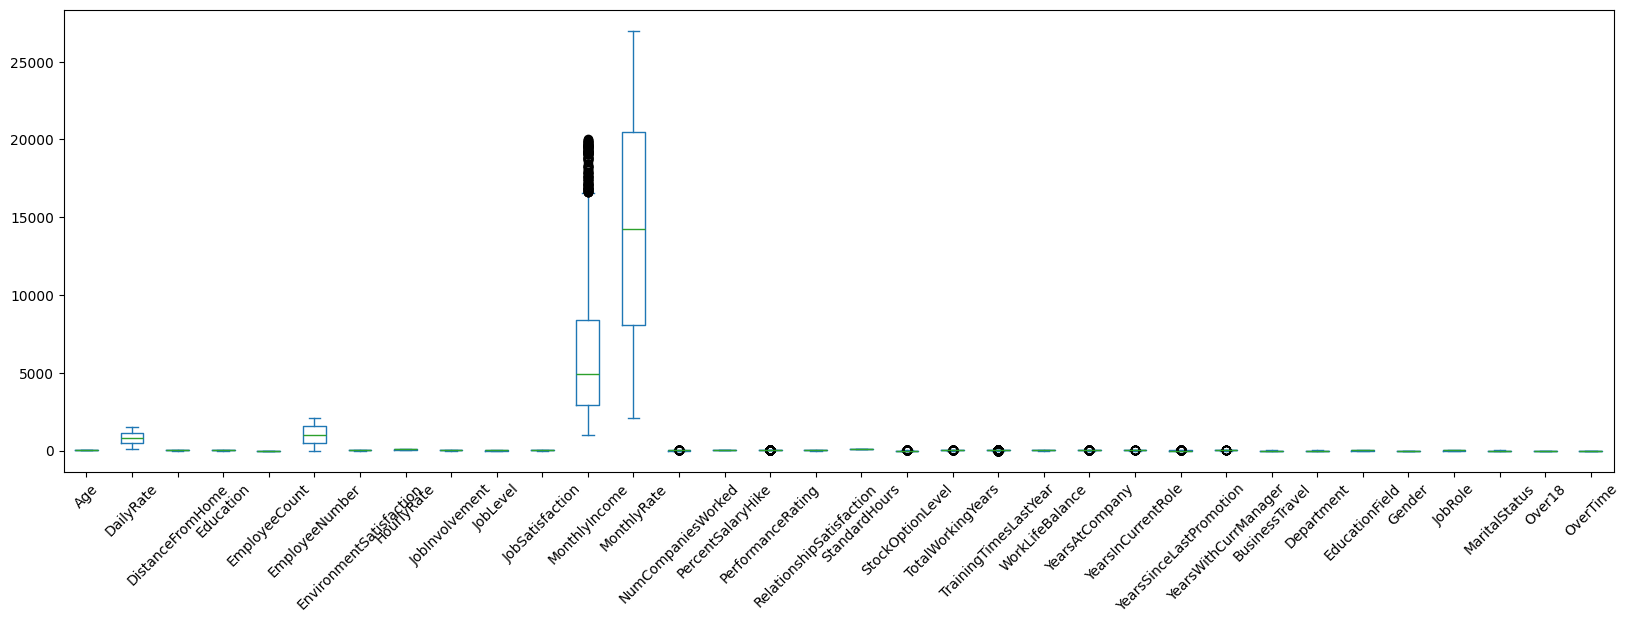

In [ ]:
# Checking outliers in the dataset
df_concat.plot(kind='box', figsize=(20,6))
plt.xticks(rotation=45)

From the above visualization, we see that

* MonthlyIncome and MonthlyRate display large spreads and multiple outliers, indicating high income variability among employees.
* JobSatisfaction and JobLevel have some mild outliers, but overall distributions are consistent.
* Features like Age, DistanceFromHome, PercentSalaryHike, and WorkLifeBalance are evenly spread without extreme deviations.
  
So, normalization needs to be done for numerical columns.

# **Normalization**

In [ ]:
# I'll implement standardscaler method to normalize the dataset.

column_names=df_concat.columns

Scaler=StandardScaler()
df_concat=Scaler.fit_transform(df_concat)

In [ ]:
# converting numerical_col to Dataframe

X=pd.DataFrame(df_concat, columns=column_names)
X.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-1.701283,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,-1.150554,-0.426230,-1.584178,0.0,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,-0.590048,-1.401512,-1.021863,-1.224745,-1.098984,-1.236820,0.0,-1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,-1.699621,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,2.129306,2.346151,1.191438,0.0,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,0.913194,0.493817,-1.021863,0.816497,-0.668527,0.133282,0.0,0.628241
2,0.008343,1.414363,-0.887515,-0.891688,0.0,-1.696298,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,-0.057267,-0.426230,-0.658973,0.0,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,-0.590048,0.493817,-0.323194,0.816497,-0.238069,-1.236820,0.0,-1.591746
3,-0.429664,1.461466,-0.764121,1.061787,0.0,-1.694636,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,-1.150554,-0.426230,0.266233,0.0,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,0.913194,0.493817,-1.021863,-1.224745,-0.668527,0.133282,0.0,-1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.691313,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.877232,-0.426230,1.191438,0.0,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.590048,0.493817,0.375475,0.816497,-0.238069,0.133282,0.0,0.628241


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# **Logistic Regression**

In [ ]:
# Logistic regression

LR_model = LogisticRegression()
LR_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred_LR = LR_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_LR))

              precision    recall  f1-score   support

          No       0.89      0.97      0.93       380
         Yes       0.56      0.25      0.34        61

    accuracy                           0.87       441
   macro avg       0.72      0.61      0.63       441
weighted avg       0.84      0.87      0.85       441



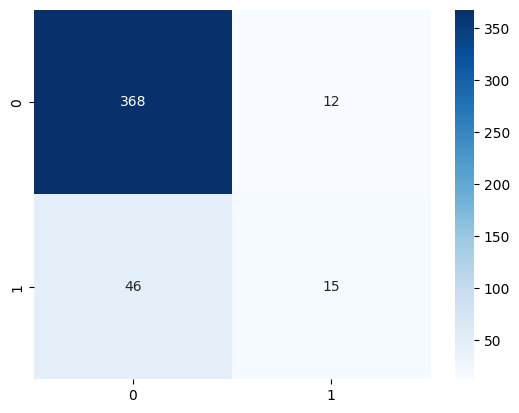

In [ ]:
cm=confusion_matrix(y_test, y_pred_LR)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

* Overall Accuracy is high at 87%, but this is misleading.

* Attrition classification is poor as it only correctly identified 25% of actual leavers (Recall: 0.25).

# **Random Forest classifier**

In [ ]:
RF_model=RandomForestClassifier(n_estimators=100)
RF_model.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred_RF=RF_model.predict(X_test)
print(classification_report(y_test, y_pred_RF))

              precision    recall  f1-score   support

          No       0.87      0.99      0.93       380
         Yes       0.67      0.10      0.17        61

    accuracy                           0.87       441
   macro avg       0.77      0.55      0.55       441
weighted avg       0.84      0.87      0.82       441



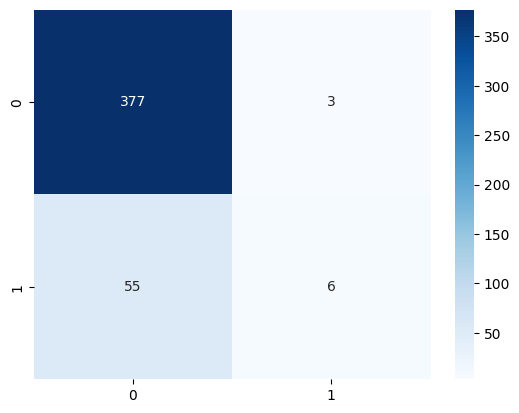

In [ ]:
cm=confusion_matrix(y_test, y_pred_RF)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

* Overall Accuracy is 86% which is also misleading.

* Attrition classification is even worse than LogisticRegression because it identified 10% of actual leavers correctly (Recall: 0.10).

**Insights**:
Both models failed because the data is imbalanced as number of people who stayed is far more than left.

# **Principle Component Analysis**

In [ ]:
pca=PCA(n_components=5)
X_pca = pca.fit_transform(X)

In [ ]:
# 1. Shape of PCA
pca.components_.shape

(5, 34)

In [ ]:
# 2.Number of samples used for fitting
pca.n_samples_

1470

In [ ]:
# 3.Eigenvalues - The actual variance values
pca.explained_variance_

array([4.74475725, 1.91884119, 1.78847911, 1.69172045, 1.3742705 ])

Insights:

* PCA condensed 34 original features into 5 principal components, streamlining the dataset while preserving essential information.

* The model was built using 1,470 employee samples, indicating that the dataset is adequate for reliable component extraction.

* The first component exhibits the greatest variance (approximately 4.74), signifying that it encompasses most of the overall variation in the data.

* The eigenvalues decrease progressively across the components, demonstrating that each subsequent component accounts for less variance.

* Together, these five components encompass the main patterns in the data, aiding in the reduction of redundancy and enhancing model efficiency.

# Auditing Process: Phase 1: Fairness Audit

In [ ]:
#Demographic Group for Analysis

original_df =pd.read_csv("/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

#use the original split and align with train-test split
test_indices = X_test.index
demographic_data = original_df.iloc[test_indices].copy()

# Explicit demographic distribution analysis
demographic_data['AgeGroup'] = pd.cut(demographic_data['Age'], bins=[0,30,50,100], labels=['Young', 'Middle', 'Senior'])

#print analysis: Representation analysis across multiple dimensions
print("Demographic Analysis:")
print(f"Gender distribution:\n{demographic_data['Gender'].value_counts()}")
print(f"\nAge Group distribution:\n{demographic_data['AgeGroup'].value_counts()}")
print(f"\nDepartment distribution:\n{demographic_data['Department'].value_counts()}")


Demographic Analysis:
Gender distribution:
Gender
Male      265
Female    176
Name: count, dtype: int64

Age Group distribution:
AgeGroup
Middle    300
Young     108
Senior     33
Name: count, dtype: int64

Department distribution:
Department
Research & Development    285
Sales                     135
Human Resources            21
Name: count, dtype: int64


**Findings from output:**


*   Senior Employees: Only 33 instances (2.2% of dataset)
*   HR Department: Only 21 instances (1.4% of dataset)
*   Young Employees: 108 instances (7.3% of dataset)

In [ ]:
def analyze_fairness(model, model_name, X_test, y_test, demographic_data, sensitive_attr):
    """
    Analyze model performance across different demographic groups
    """
    # Get predictions
    y_pred = model.predict(X_test)

    # Get prediction probabilities for binary classification
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred  # Fallback for models without probability

    results = {}

    for group_name, group_values in demographic_data[sensitive_attr].value_counts().items():
        if group_values < 5:  # Skip very small groups
            continue

        # Get indices for this group
        group_mask = demographic_data[sensitive_attr] == group_name
        group_indices = group_mask[group_mask].index

        # Ensure indices align with test set
        valid_indices = group_indices.intersection(X_test.index)

        if len(valid_indices) == 0:
            continue

        # Get performance metrics for this group
        y_true_group = y_test.loc[valid_indices]
        y_pred_group = y_pred[X_test.index.get_indexer(valid_indices)]

        # Calculate metrics
        accuracy = accuracy_score(y_true_group, y_pred_group)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true_group, y_pred_group, average='binary', pos_label = 'Yes', zero_division=0
        )

        # Calculate false positive rate
        tn, fp, fn, tp = confusion_matrix(y_true_group, y_pred_group).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        # Calculate selection rate (proportion predicted as positive)
        selection_rate = np.mean(y_pred_group == 'Yes')

        results[group_name] = {
            'n_samples': len(valid_indices),
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'false_positive_rate': fpr,
            'selection_rate': selection_rate
        }

    return results


In [ ]:
#convert y_test to binary for our analysis
y_test_binary = (y_test == 'Yes').astype(int)

#what are those sensitive attributes:
sensitive_attributes = ['Gender', 'AgeGroup', 'Department' , 'MaritalStatus']

fairness_results ={}

print("Fairness Analysis:")

for attr in sensitive_attributes:
  lr_results = analyze_fairness(LR_model, 'Logistic Regression', X_test, y_test, demographic_data, attr)
  rf_results = analyze_fairness(RF_model, 'Random Forest', X_test, y_test, demographic_data, attr)

  fairness_results[attr] = {
      'Logistic Regression': lr_results,
      'Random Forest': rf_results
  }

  print(f"{'Group':<15}, {'Model':<20} {'Recall':<8} {'FPR':<8} {'Selection Rate':<15}")
  print('-'*60)

  for group_name in lr_results.keys():
    lr_recall = lr_results[group_name]['recall']
    rf_recall = rf_results[group_name]['recall']
    lr_fpr = lr_results[group_name]['false_positive_rate']
    rf_fpr = rf_results[group_name]['false_positive_rate']
    lr_selection_rate = lr_results[group_name]['selection_rate']
    rf_selection_rate = rf_results[group_name]['selection_rate']

    print(f"{group_name:<15} {'Logistic Regression':<20} {lr_recall:<.3f} {lr_fpr:<.3f} {lr_selection_rate:.3f}")
    print(f"{group_name:<15} {'Random Forest':<20} {rf_recall:<.3f} {rf_fpr:<.3f} {rf_selection_rate:.3f}")

    print("-"*60)

Fairness Analysis:
Group          , Model                Recall   FPR      Selection Rate 
------------------------------------------------------------
Male            Logistic Regression  0.270 0.026 0.060
Male            Random Forest        0.081 0.009 0.019
------------------------------------------------------------
Female          Logistic Regression  0.208 0.039 0.062
Female          Random Forest        0.125 0.007 0.023
------------------------------------------------------------
Group          , Model                Recall   FPR      Selection Rate 
------------------------------------------------------------
Middle          Logistic Regression  0.231 0.019 0.047
Middle          Random Forest        0.026 0.004 0.007
------------------------------------------------------------
Young           Logistic Regression  0.316 0.067 0.111
Young           Random Forest        0.263 0.022 0.065
------------------------------------------------------------
Senior          Logistic Regres

In [ ]:
#Calculating Fairness metrics:
def calculate_fairness_disparities(fairness_results):

  fairness_metrics = {}
  for attr, models_results in fairness_results.items():
    fairness_metrics[attr] = {}

    for model_name, groups in models_results.items():
      if len(groups) < 2:
        continue

      recalls = [data['recall'] for data in groups.values()]
      fprs = [data['false_positive_rate'] for data in groups.values()]
      selection_rates = [data['selection_rate'] for data in groups.values()]

      fairness_metrics[attr][model_name]={
          'recall_disparity': max(recalls) - min(recalls), # Equal Opportunity
          'fpr_disparity': max(fprs)- min(fprs), # Error Rate Fairness
          'selection_rate_disparity': max(selection_rates) - min(selection_rates) #statistical Parity
      }

  return fairness_metrics


In [ ]:
#compute and display fairness metrics
fairness_metrics = calculate_fairness_disparities(fairness_results)
print("\nFairness Metrics:")
print('=='*50)

for attr, models in fairness_metrics.items():
  print(f"Attribute: {attr}")
  for model_name, metrics in models.items():
    print(f"{model_name}:")
    print(f"Recall Disparity: {metrics['recall_disparity']:.3f}")
    print(f"FPR Disparity: {metrics['fpr_disparity']:.3f}")
    print(f"Selection rate Disparity: {metrics['selection_rate_disparity']:.3f}")



Fairness Metrics:
Attribute: Gender
Logistic Regression:
Recall Disparity: 0.062
FPR Disparity: 0.013
Selection rate Disparity: 0.002
Random Forest:
Recall Disparity: 0.044
FPR Disparity: 0.002
Selection rate Disparity: 0.004
Attribute: AgeGroup
Logistic Regression:
Recall Disparity: 0.316
FPR Disparity: 0.048
Selection rate Disparity: 0.081
Random Forest:
Recall Disparity: 0.263
FPR Disparity: 0.022
Selection rate Disparity: 0.065
Attribute: Department
Logistic Regression:
Recall Disparity: 0.348
FPR Disparity: 0.036
Selection rate Disparity: 0.081
Random Forest:
Recall Disparity: 0.457
FPR Disparity: 0.009
Selection rate Disparity: 0.080
Attribute: MaritalStatus
Logistic Regression:
Recall Disparity: 0.217
FPR Disparity: 0.056
Selection rate Disparity: 0.086
Random Forest:
Recall Disparity: 0.200
FPR Disparity: 0.024
Selection rate Disparity: 0.053


Fairness comparisons for Gender:


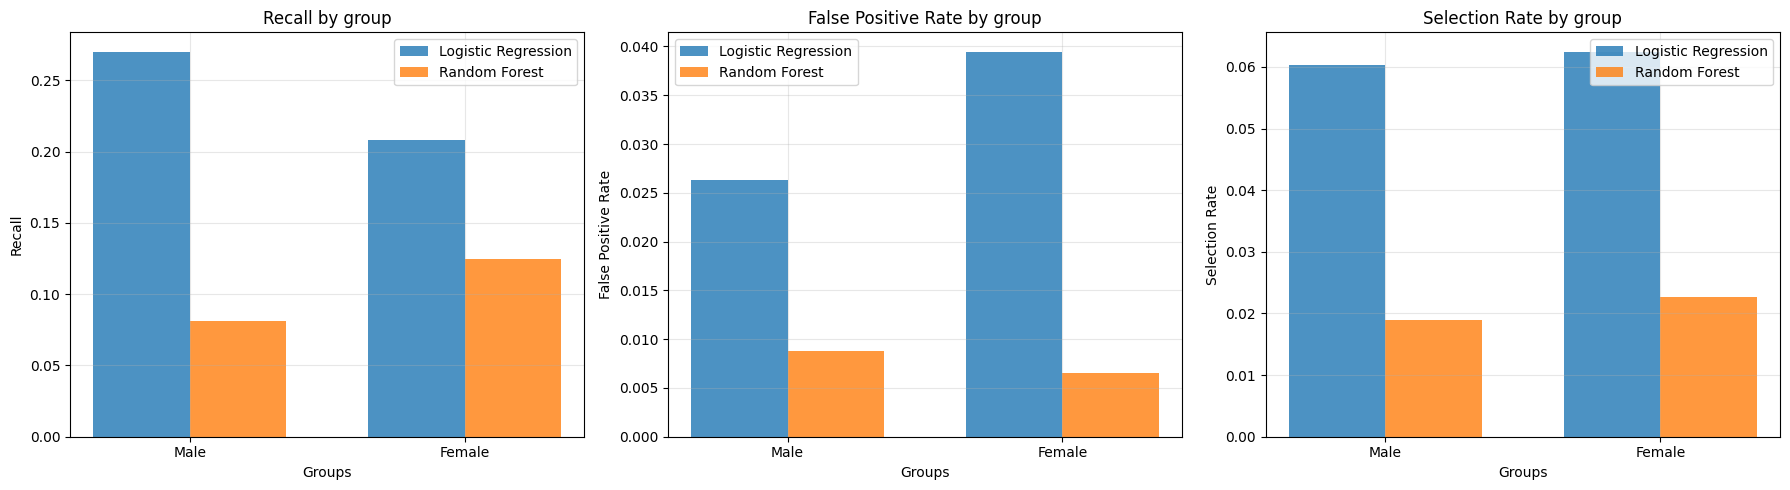

Fairness comparisons for AgeGroup:


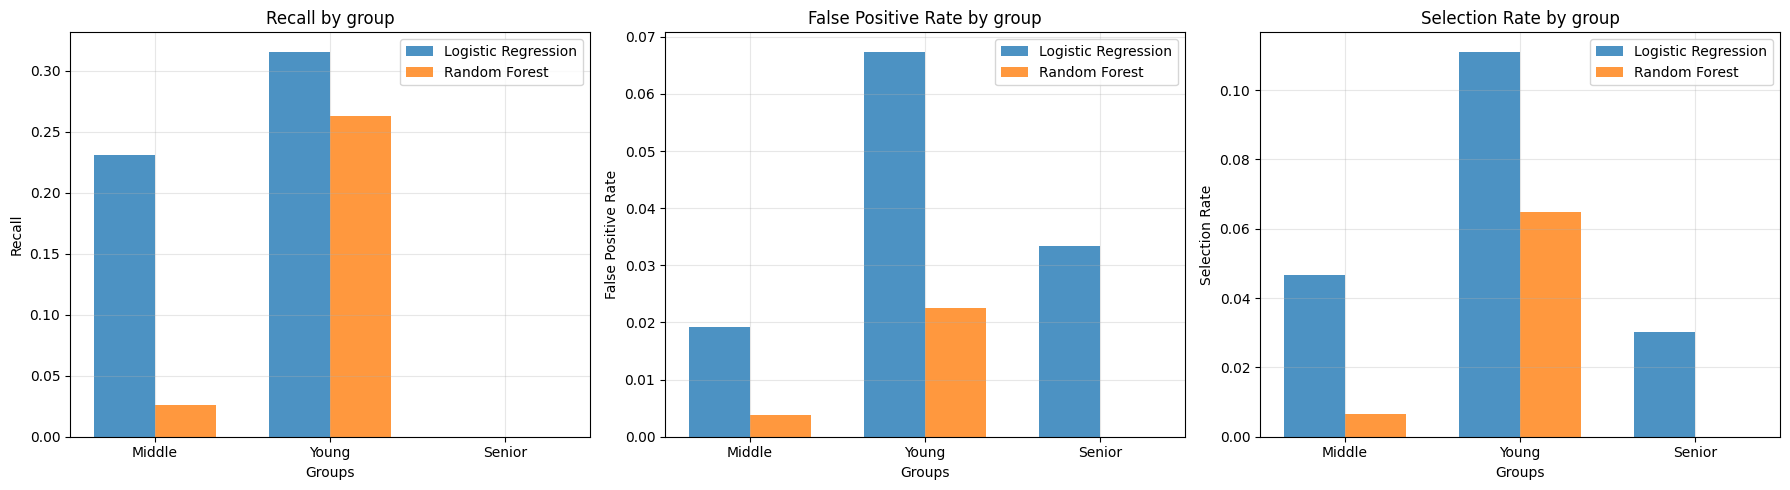

Fairness comparisons for Department:


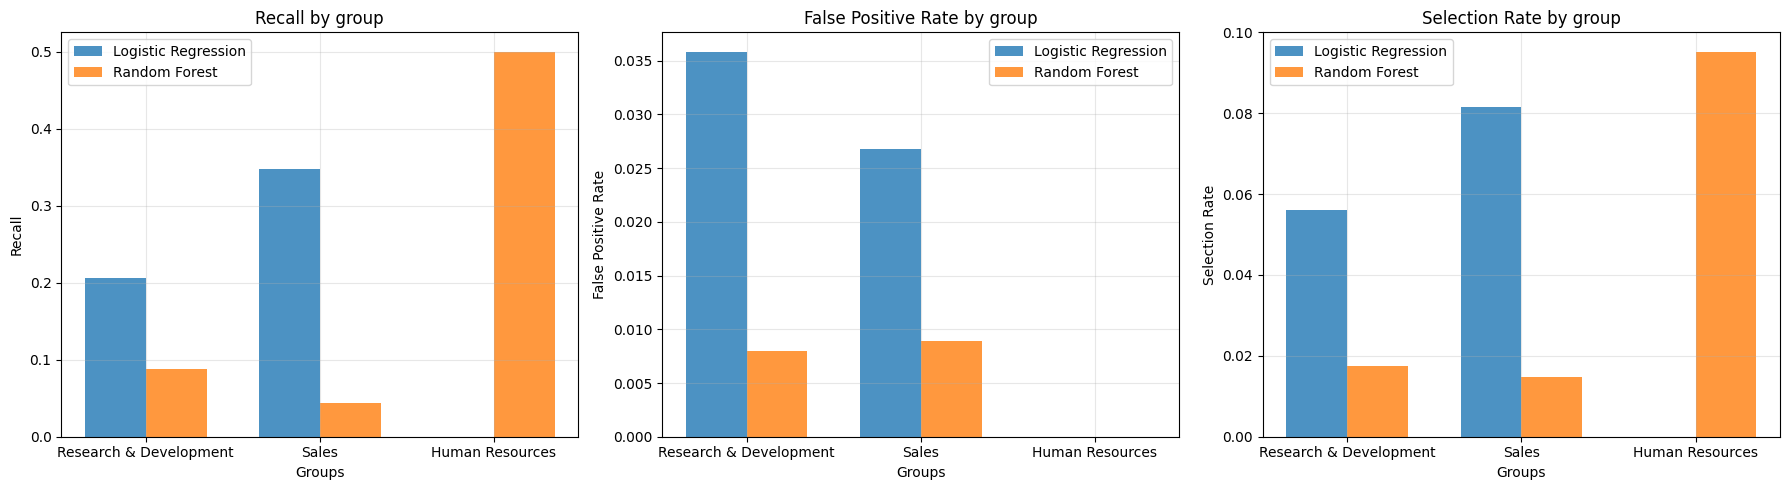

Fairness comparisons for MaritalStatus:


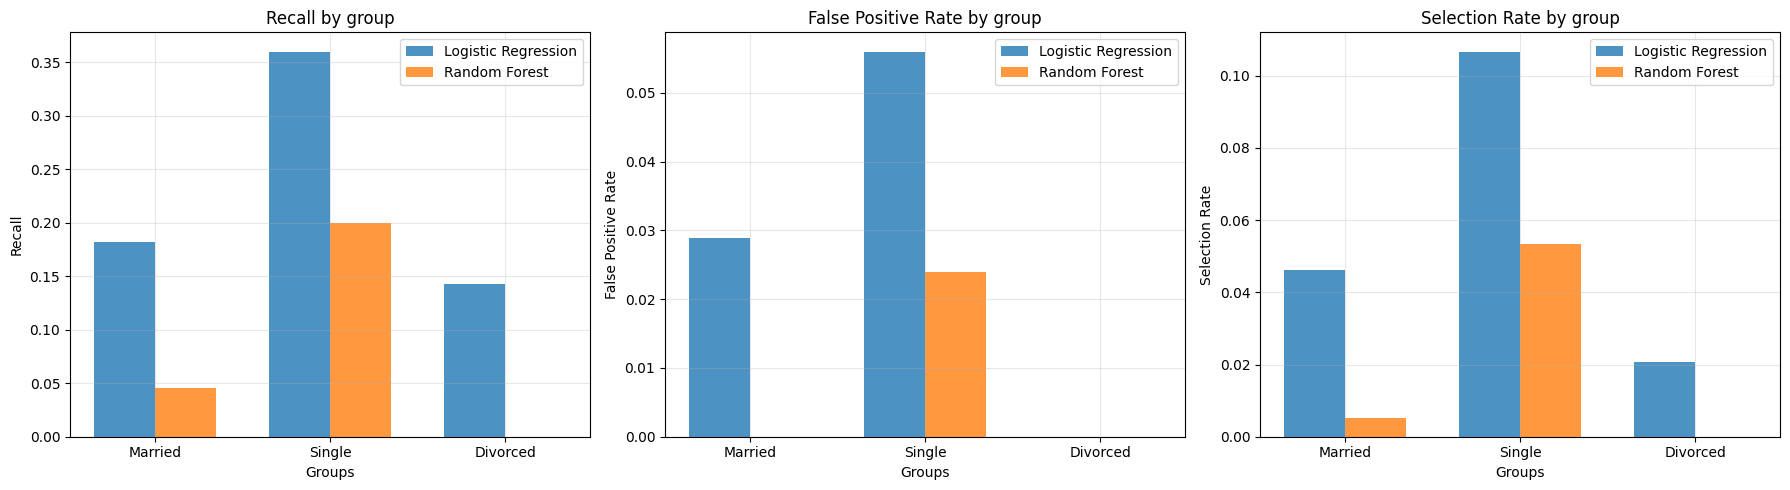

In [ ]:
def plot_fairness_comparisons(fairness_results, attribute):
  fig, axes = plt.subplots(1, 3, figsize=(18, 5))
  metrics = ['recall', 'false_positive_rate', 'selection_rate']
  titles = ['Recall by group', 'False Positive Rate by group', 'Selection Rate by group']

  for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]

    # model names to match the keys in fairness_results
    groups = list(fairness_results[attribute]['Logistic Regression'].keys())
    lr_values = [fairness_results[attribute]['Logistic Regression'][g][metric] for g in groups]
    rf_values = [fairness_results[attribute]['Random Forest'][g][metric] for g in groups]

    x = np.arange(len(groups))
    width = 0.35

    ax.bar(x - width/2, lr_values, width, label='Logistic Regression', alpha=0.8)
    ax.bar(x + width/2, rf_values, width, label='Random Forest', alpha=0.8)

    ax.set_xlabel('Groups')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.legend()
    ax.grid(True, alpha=0.3)


  plt.tight_layout()
  plt.show()

for attribute in sensitive_attributes:
  # 'attr' to 'attribute' for consistent loop variable usage
  if attribute in fairness_results:
    print(f"Fairness comparisons for {attribute}:")
    plot_fairness_comparisons(fairness_results, attribute)


# Phase 2: Explainability Audit. Shap

In [ ]:
#Key insights from Fairness Analysis:

print("Key insights from Fairness Analysis:")
print("-"*50)

bias_issues = []

for attr, models in fairness_metrics.items():
  for model_name, metrics in models.items():
    if metrics['recall_disparity'] > 0.1:
      bias_issues.append(f"{model_name} shows a high recall disparity ({metrics['recall_disparity']:.3f}) in {attr}")

if bias_issues:
  print("Potential Biases issues found:")
  for issue in bias_issues:
    print(f"- {issue}")
  else:
    print("No biases issues found.")


Key insights from Fairness Analysis:
--------------------------------------------------
Potential Biases issues found:
- Logistic Regression shows a high recall disparity (0.316) in AgeGroup
- Random Forest shows a high recall disparity (0.263) in AgeGroup
- Logistic Regression shows a high recall disparity (0.348) in Department
- Random Forest shows a high recall disparity (0.457) in Department
- Logistic Regression shows a high recall disparity (0.217) in MaritalStatus
- Random Forest shows a high recall disparity (0.200) in MaritalStatus
No biases issues found.


Global Feature Importance for Logistic Regression:


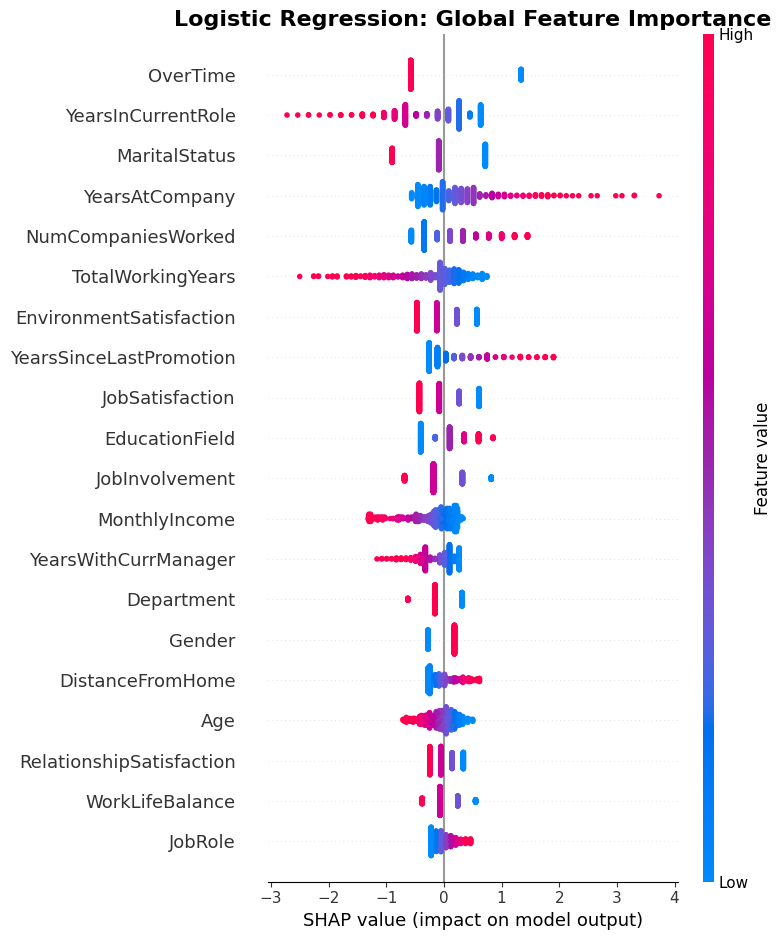

In [ ]:
#Using SHAP to create Analysis for Logistic Regression:

#create Explainer
explainer_lr = shap.Explainer(LR_model, X_train, feature_names=X.columns)
shap_values_lr = explainer_lr(X_test)

#find global feature importance
print("Global Feature Importance for Logistic Regression:")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lr, X_test, feature_names=X.columns, show=False)
plt.title("Logistic Regression: Global Feature Importance", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

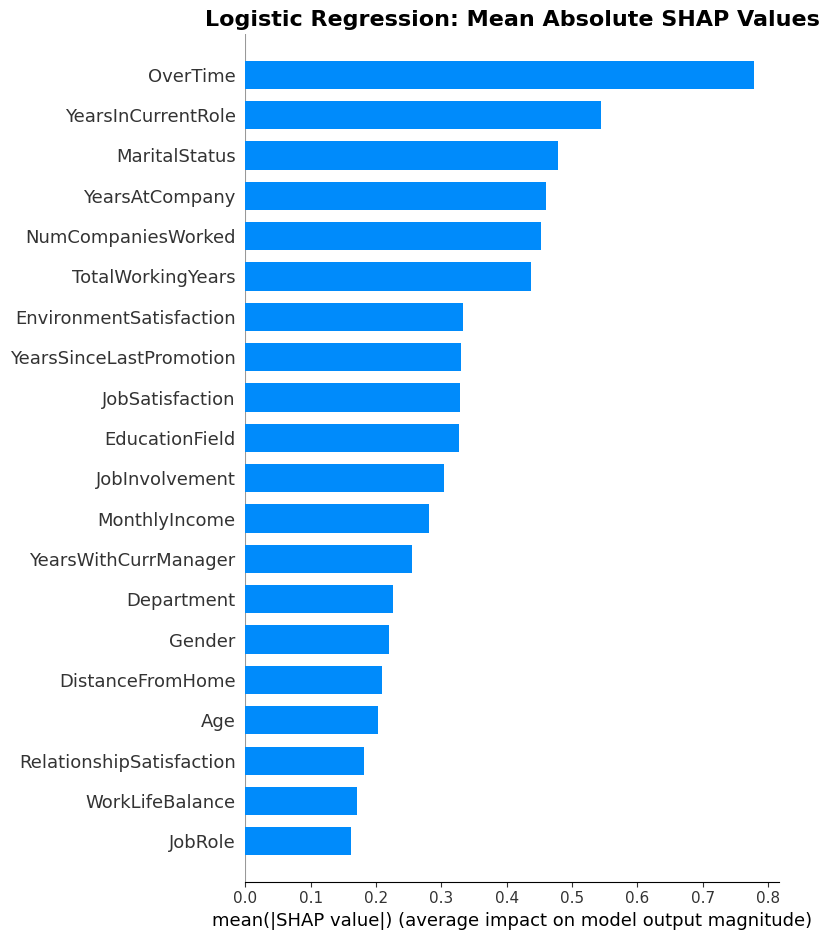

In [ ]:
#Bar plot for mean absolute SHAP values In LR:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lr, X_test, feature_names=X.columns, plot_type="bar", show=False)
plt.title("Logistic Regression: Mean Absolute SHAP Values", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Expected value (base rate): 0.172
Global Feature Importance for Random Forest:


<Figure size 1000x600 with 0 Axes>

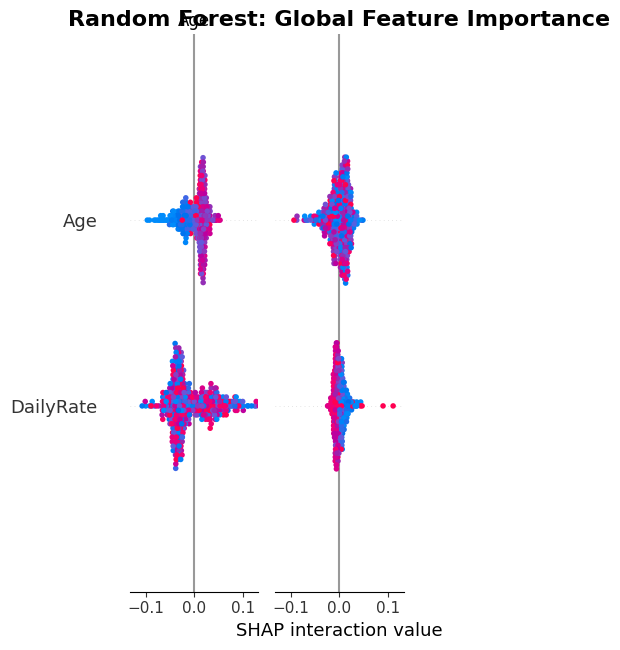

In [ ]:
#SHAP for RANDO FOREEEEST

explainer_rf = shap.TreeExplainer(RF_model)
shap_values_rf_all = explainer_rf.shap_values(X_test)

# Determine the SHAP values and expected value for the positive class ('Yes')
# This logic should correctly extract the values regardless of whether shap_values_rf_all is a list or a single 3D array.
if isinstance(shap_values_rf_all, list):
  # If shap_values_rf_all is a list, it contains one array per class. We want the second one (index 1) for 'Yes'.
  shap_values_rf = shap_values_rf_all[1]
  expected_value_rf = explainer_rf.expected_value[1]
else:
  # If shap_values_rf_all is a 3D array (n_samples, n_features, n_classes), keep it as 3D for summary_plot
  # and ensure expected_value_rf refers to the positive class's expected value.
  shap_values_rf = shap_values_rf_all
  expected_value_rf = explainer_rf.expected_value[1]

print(f"Expected value (base rate): {expected_value_rf:.3f}")

#Global Feature Importance
print("Global Feature Importance for Random Forest:")
plt.figure(figsize=(10, 6))
# shap.summary_plot can handle a 3D array (n_samples, n_features, n_classes) and will typically
# default to plotting for the positive class (index 1) for binary classification.
# If shap_values_rf is already 2D (from the 'if' block), it still works.
shap.summary_plot(shap_values_rf, X_test, feature_names=X.columns, show=False)
plt.title("Random Forest: Global Feature Importance", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

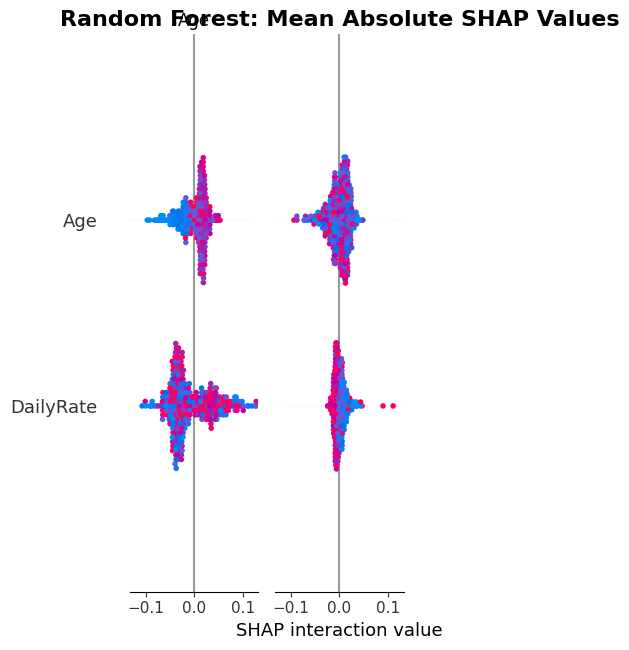

In [ ]:
#Bar plot for Randooo Forest mean absolute value SHAP values:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf, X_test, feature_names=X.columns, plot_type="bar", show=False)
plt.title("Random Forest: Mean Absolute SHAP Values", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 Most important Features (by % comparisons):
feature                   LR       RF       Difference  
----------------------------------------------------------------------
OverTime                    10.7%   12.2%       -1.5%
YearsInCurrentRole           7.5%    4.3%        3.3%
MaritalStatus                6.6%    5.5%        1.2%
YearsAtCompany               6.3%    3.9%        2.4%
NumCompaniesWorked           6.2%    4.6%        1.6%
TotalWorkingYears            6.0%    4.5%        1.5%
EnvironmentSatisfaction      4.6%    2.4%        2.2%
YearsSinceLastPromotion      4.6%    2.3%        2.3%
JobSatisfaction              4.5%    2.5%        2.1%
EducationField               4.5%    3.9%        0.6%


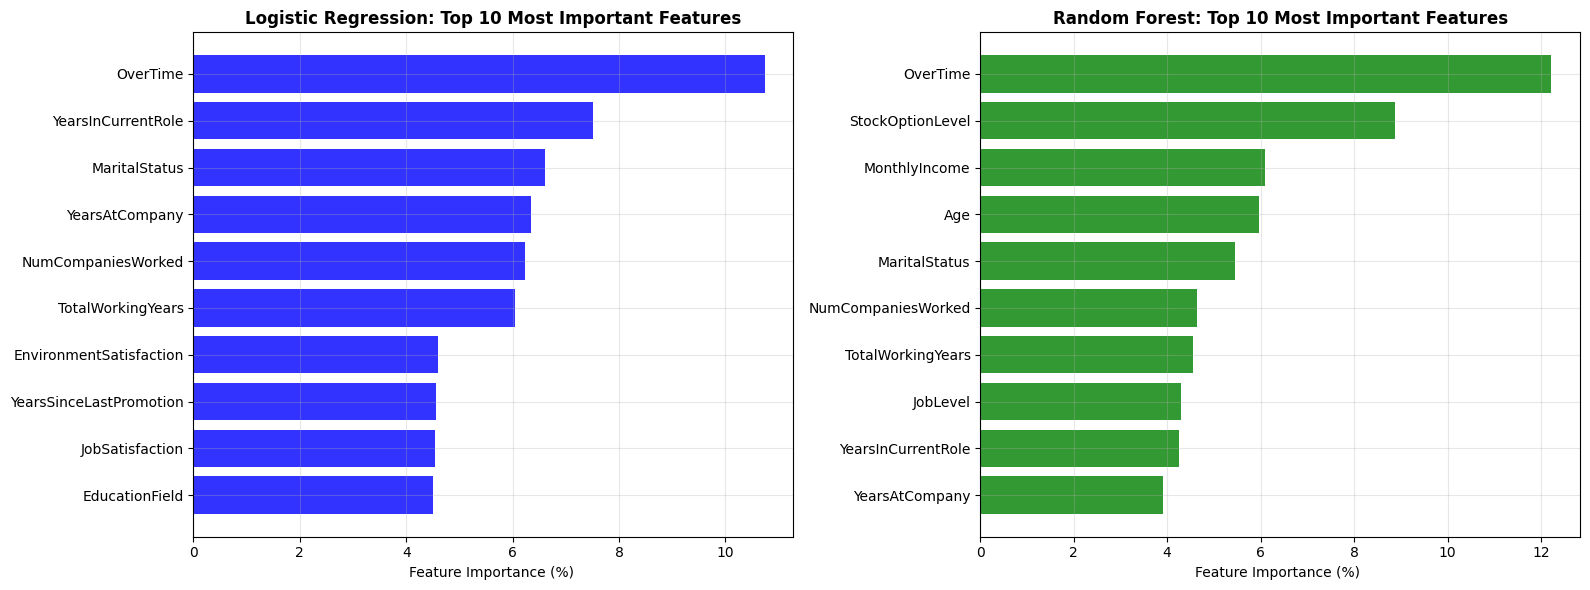

In [ ]:
#Compare them both: Quantitative feature importance comparison
lr_importance = np.mean(np.abs(shap_values_lr.values), axis=0)
#  using SHAP values for the positive class (index 1) from the 3D array
rf_importance = np.mean(np.abs(shap_values_rf[:, :, 1]), axis=0)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Logistic Regression': lr_importance,
    'Random Forest': rf_importance
})

# Calculate sums, handling potential division by zero
lr_sum = importance_df['Logistic Regression'].sum()
rf_sum = importance_df['Random Forest'].sum()

if lr_sum != 0:
    importance_df['LR_Percent'] = (importance_df['Logistic Regression'] / lr_sum) * 100
else:
    importance_df['LR_Percent'] = 0.0 # Assign 0 if sum is zero to avoid NaN/inf

if rf_sum != 0:
    importance_df['RF_Percent'] = (importance_df['Random Forest'] / rf_sum) * 100
else:
    importance_df['RF_Percent'] = 0.0 # Assign 0 if sum is zero to avoid NaN/inf

importance_df = importance_df.sort_values(by='LR_Percent', ascending=False)

print("Top 10 Most important Features (by % comparisons):")
print(f"{'feature':<25} {'LR':<8} {'RF':<8} {'Difference':<12}")
print('-'*70)

#make formatting readable, handling non-finite numbers
for _, row in importance_df.head(10).iterrows():
  diff = row['LR_Percent'] - row['RF_Percent']

  formatted_lr = f"{row['LR_Percent']:>6.1f}%" if np.isfinite(row['LR_Percent']) else f"{str(row['LR_Percent']):>6s}"
  formatted_rf = f"{row['RF_Percent']:>6.1f}%" if np.isfinite(row['RF_Percent']) else f"{str(row['RF_Percent']):>6s}"
  formatted_diff = f"{diff:>10.1f}%" if np.isfinite(diff) else f"{str(diff):>10s}"

  print(f"{row['Feature']:<25} {formatted_lr} {formatted_rf} {formatted_diff}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression features
lr_top10 = importance_df.head(10).sort_values(by='LR_Percent', ascending=True) # Sort for plotting (smallest at top for barh)
ax1.barh(lr_top10['Feature'], lr_top10['LR_Percent'], color='blue', alpha=0.8)
ax1.set_xlabel('Feature Importance (%) ')
ax1.set_title('Logistic Regression: Top 10 Most Important Features', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Random Forest features
# Using RF_Percent, sort by RF_Percent, and plot on ax2
rf_top10 = importance_df.sort_values(by='RF_Percent', ascending=False).head(10) # Get top 10 RF features
rf_top10 = rf_top10.sort_values(by='RF_Percent', ascending=True) # Sort for plotting (smallest at top for barh)
ax2.barh(rf_top10['Feature'], rf_top10['RF_Percent'], color='green', alpha=0.8)
ax2.set_xlabel('Feature Importance (%) ')
ax2.set_title('Random Forest: Top 10 Most Important Features', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Available sensitive features: ['Age', 'Gender', 'Department', 'MaritalStatus']

 Dependence plot for Age:


<Figure size 1000x400 with 0 Axes>

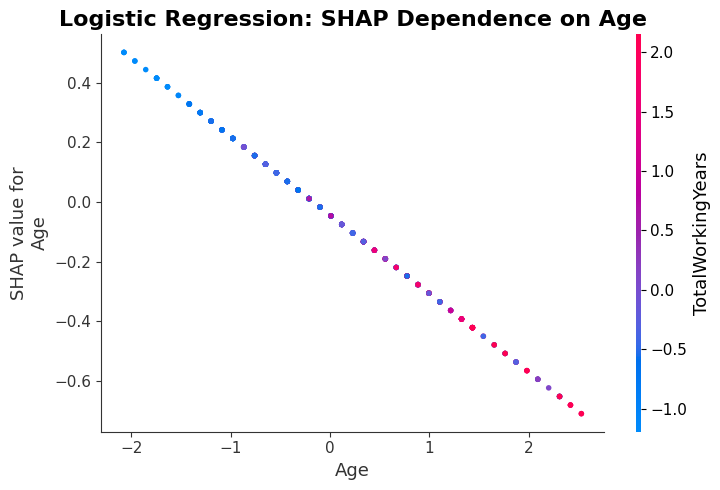

<Figure size 1000x400 with 0 Axes>

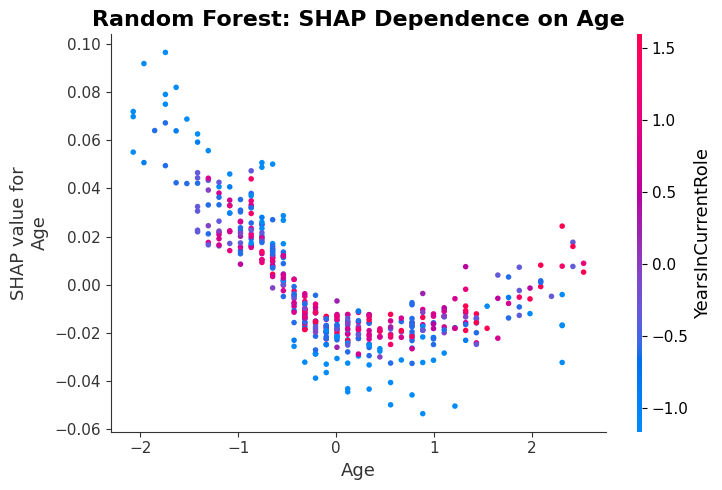


 Dependence plot for Gender:


<Figure size 1000x400 with 0 Axes>

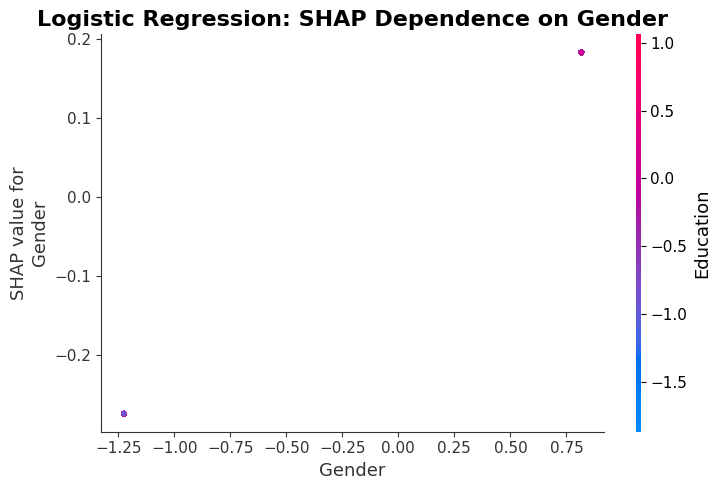

<Figure size 1000x400 with 0 Axes>

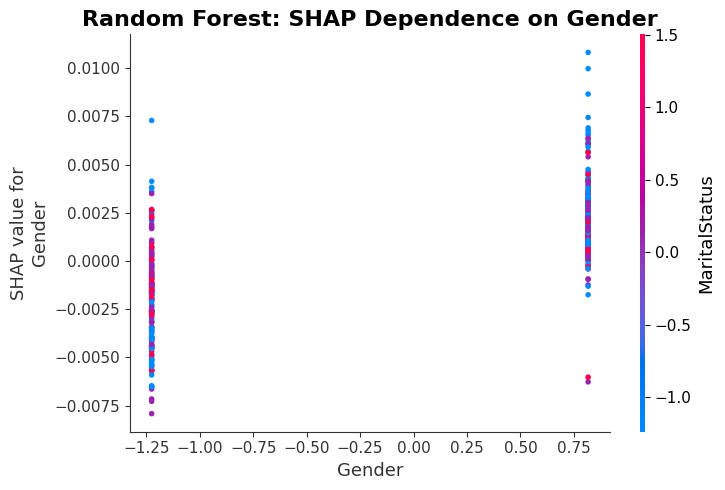


 Dependence plot for Department:


<Figure size 1000x400 with 0 Axes>

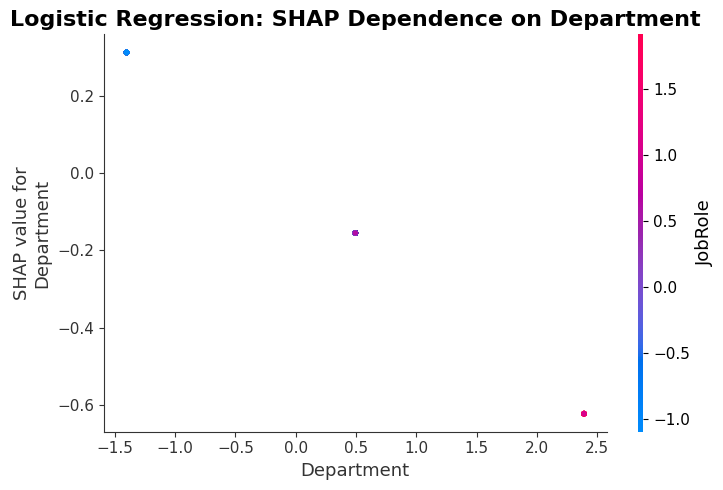

<Figure size 1000x400 with 0 Axes>

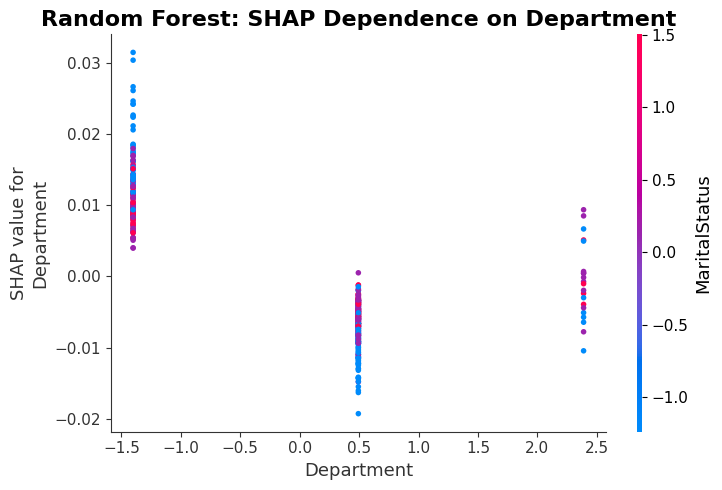


 Dependence plot for MaritalStatus:


<Figure size 1000x400 with 0 Axes>

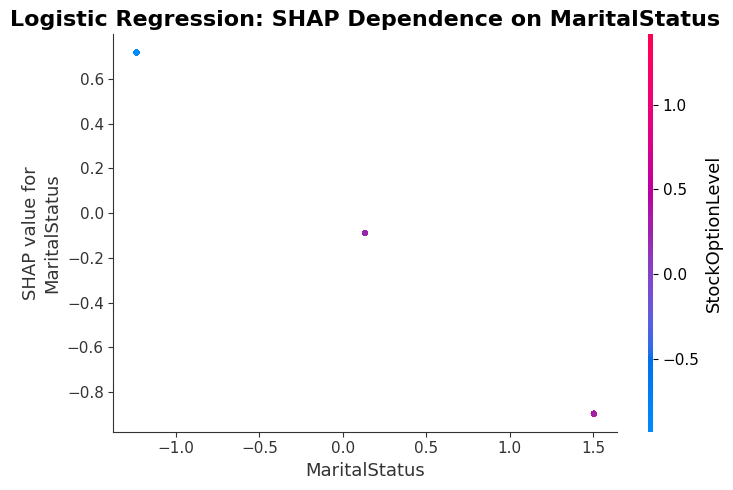

<Figure size 1000x400 with 0 Axes>

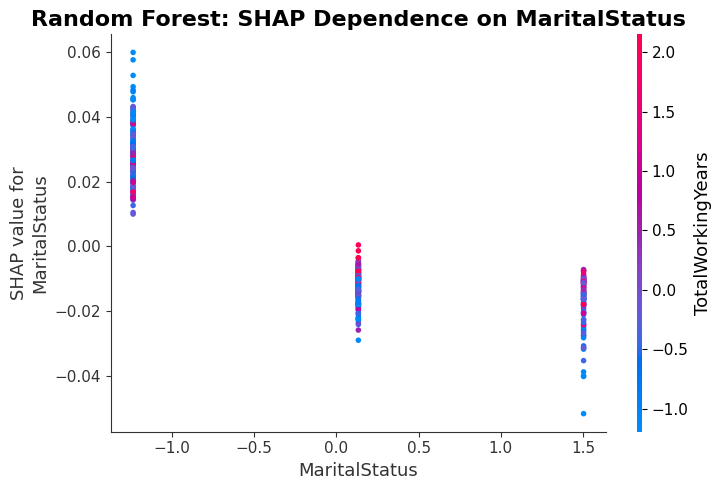

In [ ]:
#Focusing on sensitive features that has been identified in fairness analaysis
sensitive_features = ['Age', 'Gender', 'Department', 'MaritalStatus']

#Do they exist ?
available_sensitive = [f for f in sensitive_features if f in X.columns]
print(f"Available sensitive features: {available_sensitive}")


if available_sensitive:
  for feature in available_sensitive:
    if feature in X.columns:
      print(f"\n Dependence plot for {feature}:")
      plt.figure(figsize=(10, 4))

      #For logistic Regression
      shap.dependence_plot(
          feature,
          shap_values_lr.values,
          X_test,
          feature_names=X.columns,
          show=False
      )

      plt.title(f"Logistic Regression: SHAP Dependence on {feature}", fontsize=16, fontweight='bold')
      plt.tight_layout()
      plt.show()

      #For Random Forest
      plt.figure(figsize=(10, 4))
      shap.dependence_plot(
          feature,
          shap_values_rf[:, :, 1], # Selecting SHAP values for the positive class (index 1)
          X_test,
          feature_names=X.columns,
          show=False
      )
      plt.title(f"Random Forest: SHAP Dependence on {feature}", fontsize=16, fontweight='bold')
      plt.tight_layout()
      plt.show()


In [ ]:
# Lets look at some individual cases. we can use different age groups and departments

lr_probs = LR_model.predict_proba(X_test)[:, 1]
rf_probs = RF_model.predict_proba(X_test)[:, 1]

#result dataframe for analysis:
results_df = X_test.copy()
results_df['Actual_Attrition'] = y_test
results_df['LR_Prediction'] = LR_model.predict(X_test)
results_df['LR_Probability'] = lr_probs
results_df['RF_Prediction'] = RF_model.predict(X_test)
results_df['RF_Probability'] = rf_probs

for col in ['Age', 'Department', 'MaritialStatus']:
 if col in demographic_data.columns and col in original_df.columns:
  results_df[col] = demographic_data[col]

print("Sample individual prediction:")
print(results_df[['Actual_Attrition', 'LR_Prediction', 'RF_Prediction', 'LR_Probability', 'RF_Probability','Age', 'Gender', 'Department']].head(10))


Sample individual prediction:
     Actual_Attrition LR_Prediction RF_Prediction  LR_Probability  \
1041               No            No            No        0.073507   
184                No            No            No        0.007182   
1222              Yes            No           Yes        0.488178   
67                 No            No            No        0.004436   
220                No            No            No        0.024527   
494                No            No            No        0.247104   
430                No            No            No        0.217182   
240                No            No            No        0.035621   
218                No            No            No        0.115875   
49                 No            No            No        0.012498   

      RF_Probability  Age    Gender              Department  
1041            0.22   28  0.816497                   Sales  
184             0.04   53 -1.224745  Research & Development  
1222            0.54   2

In [ ]:
#Force plots for a specific interesting cases or niche examples...

shap.initjs() #initialize SHAP apparently putting it in the same cell will force it

# Strategic case selection based on risk profiles

young_high_risk_indices = results_df[(results_df['Age'] < 30) & (results_df['LR_Probability'] > 0.7)].index
senior_low_risk_indices = results_df[(results_df['Age'] > 50) & (results_df['LR_Probability'] > 0.1)].index

if len(young_high_risk_indices) >  0 and len(senior_low_risk_indices) > 0:
  young_label_idx = young_high_risk_indices[0]
  senior_label_idx = senior_low_risk_indices[0]

  # Get the positional index for shap_values and X_test.iloc
  young_pos = X_test.index.get_loc(young_label_idx)
  senior_pos = X_test.index.get_loc(senior_label_idx)

  print(f"Case 1: Young employee (Age: {original_df.loc[young_label_idx, 'Age']}) predicted HIGH risks!")
  print(f"LR Probability: {results_df.loc[young_label_idx, 'LR_Probability']:.3f}, RF Probability: {results_df.loc[young_label_idx, 'RF_Probability']:.3f}")

  print("\nLR Force Plot for Young High-Risk:")
  display(shap.force_plot(explainer_lr.expected_value, shap_values_lr.values[young_pos,:], X_test.iloc[young_pos,:]))

  print("\nRF Force Plot for Young High-Risk:")
  display(shap.force_plot(expected_value_rf, shap_values_rf[young_pos,:,1], X_test.iloc[young_pos,:]))

  print(f"\nCase 2: Senior employee (Age: {original_df.loc[senior_label_idx, 'Age']}) predicted LOW risks!")
  print(f"LR Probability: {results_df.loc[senior_label_idx, 'LR_Probability']:.3f}, RF Probability: {results_df.loc[senior_label_idx, 'RF_Probability']:.3f}")

  print("\nLR Force Plot for Senior Low-Risk:")
  display(shap.force_plot(explainer_lr.expected_value, shap_values_lr.values[senior_pos,:], X_test.iloc[senior_pos,:]))

  print("\nRF Force Plot for Senior Low-Risk:")
  display(shap.force_plot(expected_value_rf, shap_values_rf[senior_pos,:,1], X_test.iloc[senior_pos,:]))
else:
  print("Could not find sufficient examples for both young high-risk and senior low-risk cases.")

Case 1: Young employee (Age: 28) predicted HIGH risks!
LR Probability: 0.754, RF Probability: 0.430

LR Force Plot for Young High-Risk:



RF Force Plot for Young High-Risk:



Case 2: Senior employee (Age: 51) predicted LOW risks!
LR Probability: 0.200, RF Probability: 0.240

LR Force Plot for Senior Low-Risk:



RF Force Plot for Senior Low-Risk:
